In [1]:
from minio import Minio
import s3fs
import os
import matplotlib.pyplot as plt
import xarray as xr
import pickle
import numpy as np
from sympl import get_constant
import metpy
from metpy.units import units
import matplotlib.pylab as pl
import matplotlib.gridspec as gridspec
import matplotlib.transforms as mtransforms
from matplotlib.ticker import ScalarFormatter

fs = s3fs.S3FileSystem(
    client_kwargs={
        "endpoint_url": "http://192.168.1.237:9000"
    },
    key="d0d250b2541ac33f4660",
    secret="2fb32d964768bc94a3c0"
)

output_dir='/home/data/lab_project2/Steve/model_runs/dry_land/scratch/'
base_path = "climt-long-runs/dry-land/regrid-data/"
plot_path = '/home/data/lab_project2/Steve/model_runs/plotting/dl-plots/'
Rd = get_constant('gas_constant_of_dry_air', 'J kg^-1 K^-1')
Cp =\
    get_constant('heat_capacity_of_dry_air_at_constant_pressure',
                 'J kg^-1 K^-1')
g=get_constant('gravitational_acceleration',
                 'm s^-2')
DSE2T50 = 0.0010098587974763152
DSE2T35 = 0.0010281251137810598

/home/lab_project2/.conda/envs/xCDAT/lib/python3.13/site-packages/sympl/_core/dataarray.py:6: FutureWarning: xarray subclass DataArray should explicitly define __slots__
  class DataArray(xr.DataArray):


In [2]:
climfile=output_dir+'climatology'
ds=xr.open_dataset(climfile, engine='zarr')

p1=ds['air_pressure'].fillna(ds['surface_air_pressure'])
at=ds['air_temperature'].fillna(ds['surface_temperature']).copy()
at[1:, :]=(at.values[:-1, :]+at.values[1:, :])/2; at[0, :]=(at[0, :].values[:]+ds['surface_temperature'].values[:])/2
p2=p1.copy()
p2[1:,:]=p1[:-1,:].values[:]
p2[0,:]=ds['surface_air_pressure'].values[:]

lat_rad=np.radians(ds['air_temperature'].lat)

z=(Rd*at/g*np.log(p2/p1)).cumsum(dim='lev')
    
dse_clim=Cp*ds['air_temperature']+g*z
u_clim=ds['eastward_wind']; v_clim=ds['northward_wind']; w_clim=ds['vertical_wind']

def avg_cons(x):
    return (x.values[1:]+x.values[:-1])/2

def diff_cons(x):
    return (x.values[1:]-x.values[:-1])


# change the .mean to .sum at the end of compute_dse and compute_dse_tend, 
# if youre selecting levs from 960 and upwards, 980 has nans which will
# interfere with the sum values (960 and upwards is devoid of nans), taking
# mean will help smooth it out. 

def compute_dse(ds, latc, lonc):
    # computes average DSE in the box between specified levels - units of J/kg
    
    p1=ds['air_pressure'].fillna(ds['surface_air_pressure'])
    at=ds['air_temperature'].fillna(ds['surface_temperature']).copy()
    at[:,1:]=(at.values[:,:-1]+at.values[:,1:])/2; at[:,0]=(at[:,0].values[:]+ds['surface_temperature'].values[:])/2
    p2=p1.copy()
    p2[:,1:]=p1[:,:-1].values[:]
    p2[:,0]=ds['surface_air_pressure'].values[:]
    
    lat_rad=np.radians(ds['air_temperature'].lat)
    
    z=(Rd*at/g*np.log(p2/p1)).cumsum(dim='lev')
    dse=(Cp*ds['air_temperature']+g*z).sel({'lat':slice(latc+5,latc-5),
                                            'lon':slice(lonc-5,lonc+5),'lev':slice(98000, 90000)}).weighted(np.cos(lat_rad))
    return dse.mean(dim=('lat', 'lon','lev'))

def compute_dse_tend(ds, latc, lonc):
    # computes average DSE tendency Reynolds components in the box between specified levels - units of J/kg
    
    p1=ds['air_pressure'].fillna(ds['surface_air_pressure'])
    at=ds['air_temperature'].fillna(ds['surface_temperature']).copy()
    at[:,1:]=(at.values[:,:-1]+at.values[:,1:])/2; at[:,0]=(at[:,0].values[:]+ds['surface_temperature'].values[:])/2
    p2=p1.copy()
    p2[:,1:]=p1[:,:-1].values[:]
    p2[:,0]=ds['surface_air_pressure'].values[:]
    
    lat_rad=np.radians(ds['air_temperature'].lat)
    
    z=(Rd*at/g*np.log(p2/p1)).cumsum(dim='lev')
    dse=Cp*ds['air_temperature']+g*z
    
    # adding the dse components to a list
    rey_grp=[]
    rey_grp.append(-metpy.calc.first_derivative(dse, axis='lev')/units.metre*ds['vertical_wind'])
    rey_grp.append(-metpy.calc.first_derivative(dse-dse_clim, axis='lat')*(ds['northward_wind']-v_clim))
    rey_grp.append(-metpy.calc.first_derivative(dse_clim, axis='lat')*(ds['northward_wind']-v_clim))
    rey_grp.append(-metpy.calc.first_derivative(dse-dse_clim, axis='lat')*(v_clim))
    rey_grp.append(-metpy.calc.first_derivative(dse_clim, axis='lat')*(v_clim))
    rey_grp.append(-metpy.calc.first_derivative(dse-dse_clim, axis='lon')*(ds['eastward_wind']-u_clim))
    rey_grp.append(-metpy.calc.first_derivative(dse_clim, axis='lon')*(ds['eastward_wind']-u_clim))
    rey_grp.append(-metpy.calc.first_derivative(dse-dse_clim, axis='lon')*(u_clim))
    rey_grp.append(-metpy.calc.first_derivative(dse_clim, axis='lon')*(u_clim))
    rey_grp.append(-metpy.calc.first_derivative(dse, axis='lon')*ds['eastward_wind']
                   -metpy.calc.first_derivative(dse, axis='lat')*ds['northward_wind']
                   -metpy.calc.first_derivative(dse, axis='lev')/units.metre*ds['vertical_wind'])
    
    
    rey_out=[]
    for e in rey_grp:
        rey_out.append((e).sel({'lat':slice(latc+5,latc-5), 'lon':slice(lonc-5,lonc+5),
                                'lev':slice(98000, 90000)}).weighted(np.cos(lat_rad)).mean(dim=('lat', 'lon','lev'))*86400)
    
    return rey_out

In [ ]:
    
latc=50
output_file=output_dir+'hw_'+str(latc)
with open(output_file, 'rb') as f:
    hw_master=pickle.load(f)
    
target_lons = np.arange(5, 355, 70)

mask = [lon in target_lons for lon in hw_master['lonc']]
hw_master = {key: [vals[i] for i, m in enumerate(mask) if m]
               for key, vals in hw_master.items()}
    
hw_index=1
y=1
loop=0
dse_master={'index':[], 'T':[], 'lonc':[], 'dse_low':[], 'intensity':[], 'duration':[], 'maximum':[],
            'dseres':[],'dsez':[],'dsexaa':[],'dsexca':[],'dsexac':[],'dsexcc':[],'dseyaa':[],'dseyca':[],
            'dseyac':[],'dseycc':[], 'dsetot':[]}

full_length=len(hw_master['index'])

while hw_index <= full_length:
    try:
        if hw_master['intensity'][hw_index-1] > np.quantile(hw_master['intensity'], 0.9):
            r = hw_master['run'][hw_index-1]
            zarr_path = f"{base_path}run{r}/year{y}"
            ds = xr.open_zarr(fs.get_mapper(zarr_path))

            time_slice = hw_master['time'][hw_index-1]
            ds_hw = ds.sel({'time': time_slice})
            print(hw_index , hw_master['index'][hw_index-1]); loop = 0
            
            dse_low = compute_dse(ds_hw, latc, hw_master['lonc'][hw_index-1])
            dse_tend_low = compute_dse_tend(ds_hw, latc, hw_master['lonc'][hw_index-1])
            dse_master['dse_low'].append(dse_low.values)

            dse_master['dsez'].append(avg_cons(dse_tend_low[0]))
            dse_master['dseyaa'].append(avg_cons(dse_tend_low[1]))
            dse_master['dseyca'].append(avg_cons(dse_tend_low[2]))
            dse_master['dseyac'].append(avg_cons(dse_tend_low[3]))
            dse_master['dseycc'].append(np.array(dse_tend_low[4].values))
            dse_master['dsexaa'].append(avg_cons(dse_tend_low[5]))
            dse_master['dsexca'].append(avg_cons(dse_tend_low[6]))
            dse_master['dsexac'].append(avg_cons(dse_tend_low[7]))
            dse_master['dsexcc'].append(np.array(dse_tend_low[8].values))
            dse_master['dsetot'].append(avg_cons(dse_tend_low[9]))
            dse_master['dseres'].append(diff_cons(dse_low)-avg_cons(dse_tend_low[9]))

            for e in hw_master.keys():
                if e in dse_master.keys():
                    dse_master[e].append(hw_master[e][hw_index-1])
        hw_index += 1  # always advance
    except KeyError:
        loop += 1
        if loop > 20:
            print("skipping!")
            hw_index += 1
            loop = 0
            continue
        if y < 20:
            y += 1
        else:
            y = 1
            
output_file=output_dir+'dse_rey_HI_'+str(latc)
if not os.path.isfile(output_file):
    with open(output_file, 'wb') as f:
        pickle.dump(dse_master, f)

8 8
30 175
35 180
49 194
63 362
65 364
76 375
92 499
93 500
107 652
112 657
131 834
134 837
137 840
150 976
153 979
171 1142


dsetot 5.1684930307951765e-15 2.8624074047071117e-15
dseyca 1.304038415180392e-14 7.921002627178227e-15
dseyaa -5.847524744991257e-15 6.446104279254456e-15
dsexac 1.0189036985855444e-15 4.044750507973414e-15
dsexaa -6.51458532426171e-16 4.209862126318736e-15
dsez -2.3687062676435376e-15 1.4342822599734391e-15
dseres -2.0755732081445886e-15 2.013718103298113e-15
dsetot 3.148213752776671e-15 2.2828237792016586e-15
dseyca 1.1600702798979874e-14 5.5247686886258014e-15
dseyaa -4.543490961860395e-15 4.608189137370431e-15
dsexac -3.707000441291837e-17 1.1045171054580465e-15
dsexaa -1.6085934675361359e-15 2.909961535741112e-15
dsez -1.2282093286196776e-15 5.90878400126667e-16
dseres -1.2646224706549644e-15 1.9463331812361916e-15
dsetot 2.427342091079724e-15 2.071629982484838e-15
dseyca 8.815036289651241e-15 6.2319534657363796e-15
dseyaa -5.727445776631243e-15 6.369909801271674e-15
dsexac 3.562417734809439e-16 3.5283691818950785e-15
dsexaa 3.311388842417755e-16 3.50958311424679e-15
dsez -1.3977

/tmp/ipykernel_659344/1176494724.py:131: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax1.annotate("50N - High intensity",xy=(0.56,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
/tmp/ipykernel_659344/1176494724.py:132: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax2.annotate("35N - High intensity",xy=(0.56,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
/tmp/ipykernel_659344/1176494724.py:133: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax3.annotate("50N - Low intensity",xy=(0.5725,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
/tmp/ipykernel_659344/11

Text(0.07, 0.5, 'Intensity (K)')

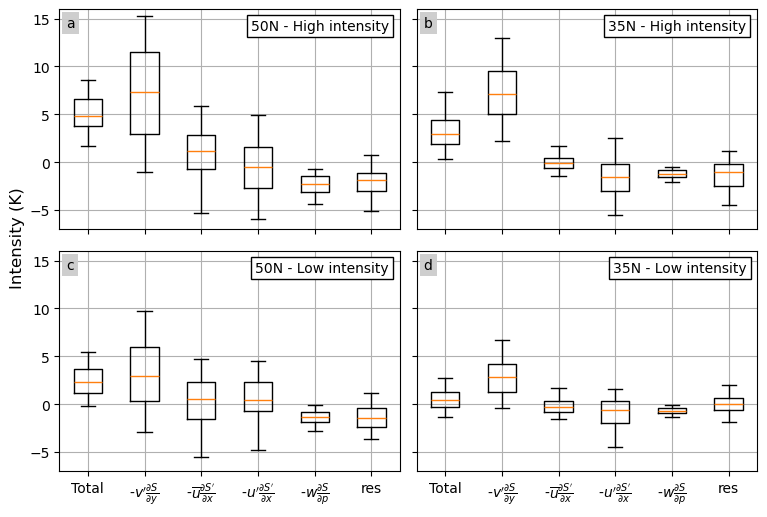

In [2]:
with open(output_dir+'dse_rey_HI_50', 'rb') as f:
    rey_HI_50 = pickle.load(f)

with open(output_dir+'dse_rey_HI_35', 'rb') as f:
    rey_HI_35 = pickle.load(f)

with open(output_dir+'dse_rey_LI_50', 'rb') as f:
    rey_LI_50 = pickle.load(f)

with open(output_dir+'dse_rey_LI_35', 'rb') as f:
    rey_LI_35 = pickle.load(f)
    
###########################################################################

def set_label(fig, ax, label):
    trans = mtransforms.ScaledTranslation(5/72, -5/72, fig.dpi_scale_trans)
    ax.text(0.0, 1.0, label, transform=ax.transAxes + trans,
            fontsize='medium', verticalalignment='top', fontfamily=None,
            bbox=dict(facecolor='0.8', edgecolor='none', pad=3.0, alpha=0.95))

formatter = ScalarFormatter()
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))

#fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
gs = gridspec.GridSpec(2, 2, hspace=0.1, wspace=0.05)
fig=pl.figure(figsize=(9,6))
ax1 = pl.subplot(gs[0, 0])
ax2 = pl.subplot(gs[0, 1]) 
ax3 = pl.subplot(gs[1, 0])
ax4 = pl.subplot(gs[1, 1])


######################### high intensity lat 50 ###########################
dse_master=rey_HI_50
x=[]
chk=[]
for d in ['dsetot','dseyca','dseyaa','dsexac','dsexaa','dsez','dseres']:
    chk.append( np.mean([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]])/1e18)
    x.append(([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]]))
    print(d, np.mean([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]])/1e18, np.std([e.cumsum().mean().item() for e in dse_master[d]])/1e18)

# combining dseyca and dseyaa
x[1] = (np.array(x[1])+np.array(x[2])).tolist()
x.pop(2)
x = [ (DSE2T50 * np.array(arr)).tolist() for arr in x ]
ax1.boxplot(x, showfliers=False, whis=(5,95))
ax1.grid()
ax1.set_xticklabels([])
#ax1.yaxis.set_major_formatter(formatter)
ax1.autoscale(axis='y')
ax1.set_ylim(-7, 16)
ax1.yaxis.get_major_locator().set_params(prune='both')
set_label(fig, ax1, 'a')


####################### high intensity lat 35 #############################
dse_master=rey_HI_35
x=[]
chk=[]
for d in ['dsetot','dseyca','dseyaa','dsexac','dsexaa','dsez','dseres']:
    chk.append( np.mean([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]])/1e18)
    x.append(([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]]))
    print(d, np.mean([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]])/1e18, np.std([e.cumsum().mean().item() for e in dse_master[d]])/1e18)
#x = np.array(x)
x[1] = (np.array(x[1])+np.array(x[2])).tolist()
x.pop(2)
x = [ (DSE2T35 * np.array(arr)).tolist() for arr in x ]
ax2.boxplot(x, showfliers=False, whis=(5,95))
ax2.grid()
ax2.set_xticklabels([])
#ax2.yaxis.set_major_formatter(formatter)
ax2.autoscale(axis='y')
ax2.set_ylim(-7, 16)
ax2.yaxis.get_major_locator().set_params(prune='both')
set_label(fig,ax2, 'b')
ax2.set_yticklabels([])

###################### low intensity lat 50 ###############################
dse_master=rey_LI_50
x=[]
chk=[]
for d in ['dsetot','dseyca','dseyaa','dsexac','dsexaa','dsez','dseres']:
    chk.append( np.mean([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]])/1e18)
    x.append(([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]]))
    print(d, np.mean([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]])/1e18, np.std([e.cumsum().mean().item() for e in dse_master[d]])/1e18)
#x = np.array(x)
x[1] = (np.array(x[1])+np.array(x[2])).tolist()
x.pop(2)
x = [ (DSE2T50 * np.array(arr)).tolist() for arr in x ]
ax3.boxplot(x, showfliers=False, whis=(5,95))
ax3.grid()
ax3.autoscale(axis='y')
ax3.set_ylim(-7, 16)
ax3.yaxis.get_major_locator().set_params(prune='both')
#ax3.yaxis.set_major_formatter(formatter)
set_label(fig,ax3, 'c')
ax3.set_xticks([1, 2, 3, 4, 5, 6], ['Total', r'-$v^\prime\frac{\partial S}{\partial y}$',
                                r'-$\overline{u}\frac{\partial S^\prime}{\partial x}$',
                                r'-$u^\prime\frac{\partial S^\prime}{\partial x}$',
                                r'-$w\frac{\partial S}{\partial p}$',
                                'res'])

###################### low intensity lat 35 ###############################
dse_master=rey_LI_35
x=[]
chk=[]
for d in ['dsetot','dseyca','dseyaa','dsexac','dsexaa','dsez','dseres']:
    chk.append( np.mean([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]])/1e18)
    x.append(([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]]))
    print(d, np.mean([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]])/1e18, np.std([e.cumsum().mean().item() for e in dse_master[d]])/1e18)

x[1] = (np.array(x[1])+np.array(x[2])).tolist()
x.pop(2)
x = [ (DSE2T35 * np.array(arr)).tolist() for arr in x ]
ax4.boxplot(x, showfliers=False, whis=(5,95))
ax4.grid()
#ax4.yaxis.set_major_formatter(formatter)
ax4.autoscale(axis='y')
ax4.set_ylim(-7, 16)
set_label(fig,ax4, 'd')
ax4.set_yticklabels([])
ax4.yaxis.get_major_locator().set_params(prune='both')
ax4.set_xticks([1, 2, 3, 4, 5, 6], ['Total', r'-$v^\prime\frac{\partial S}{\partial y}$',
                                r'-$\overline{u}\frac{\partial S^\prime}{\partial x}$',
                                r'-$u^\prime\frac{\partial S^\prime}{\partial x}$',
                                r'-$w\frac{\partial S}{\partial p}$',
                                'res'])


ax1.annotate("50N - High intensity",xy=(0.56,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
ax2.annotate("35N - High intensity",xy=(0.56,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
ax3.annotate("50N - Low intensity",xy=(0.5725,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
ax4.annotate("35N - Low intensity",xy=(0.575,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
fig.supylabel("Intensity (K)", fontsize=12, x=0.07)

#fig.savefig(plot_path+'4.pdf', bbox_inches='tight')
#fig.savefig(plot_path+'4.jpg',dpi=600, bbox_inches='tight')